# Preliminary Analysis for TriDENT

## Aims/Scope
- Sanity check: Does TriDENT work the way we think it does. This includes checking for the distributions of pre- and post-activations and verfifying if the samples are drawn properly.
- Additionally, does this give rise to the sigmoidal CDF that is noise dependent.
- How do simple models train under varying levels of SNR.
- Do models trained at a given SNR, also perform well under a larger (or smaller) SNR.
- How does additive noise affect the sparsity of hidden layer.

## Specific Plots:
<font color="yellow"> This list should be updated as new plots are added</font>
- Distributions showing the activations and pre-activations (v1 has these plots!)
- SNR vs. test performance plots
- SNR vs. sparsity plots
- More plots as required...

## Data Locations
- Data should be loaded from `/local_disk/vikrant/trident/models/snr_sweep*` pickle files.
- Script generating this data is in `/tests/snr_vs_perf_ffn_trident.py`.

In [ ]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()



In [2]:
# set latex backend for matplotlib
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'

# set the flag for stayem
system_flag = "macbook" # or mahowald

In [270]:
# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"

else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [4]:
## prediction function
def pred_step(
        model: FFN, 
        inputs: jax.Array,
        labels: jax.Array,
        # metrics: nnx.MultiMetric
    ):

    logits = model(inputs)
    # print(logits)
    logits = nnx.softmax(logits, axis=-1)
    prediction = jnp.argmax(logits, axis=-1)
    # print(prediction)
    # accuracy = -1
    accuracy = jnp.mean(prediction == labels)

    return accuracy, prediction

In [35]:
# plotting the snr vs perforamnce plots
snr_models = glob.glob(os.path.join(MODEL_PATH, "snr_sweep_iris_2026-05-13*"))
print(snr_models)

['/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.0010.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.0100.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.1000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_1.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_10.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_100.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_1000.0000.pkl']


In [36]:
test_model = snr_models[0]
test_model = pickle.load(open(test_model, "rb"))
print(test_model['configs'])
print(test_model['data'])
print(test_model['state'])

{'train_steps': 30000, 'eval_every': 1000, 'learning_rate': 0.0001, 'threshold': 0.0, 'noise_std_arr': Array([1.00000005e-03, 9.99999978e-03, 1.00000024e-01, 1.00000000e+00,
       1.00000000e+01, 1.00000000e+02, 1.00000000e+03], dtype=float32), 'layers': [4, 32, 3], 'seed': 234, 'rng_headers': ['params+0', 'dropout+1', 'activation+2', 'next+3'], 'noise_std': 0.0010000000474974513}
defaultdict(<class 'list'>, {'training_snr': 55.47074890136719, 'training_sparsity': 0.0027777778450399637})
State({
  'activation': {
    'rngs': {
      'activation': {
        'count': RngCount( # 1 (4 B)
          value=Array(30031, dtype=uint32),
          tag='activation'
        ),
        'key': RngKey( # 1 (8 B)
          value=Array((), dtype=key<fry>) overlaying:
          [  0 236],
          tag='activation'
        )
      },
      'dropout': {
        'count': RngCount( # 1 (4 B)
          value=Array(0, dtype=uint32),
          tag='dropout'
        ),
        'key': RngKey( # 1 (8 B)
       

## Calculate RMS of the signal/preactivations on entire dataset

In [ ]:
# load the data: seed=101, split=0.7
_, X_test, _, y_test = load_uci_iris(normalize=True, key=101, train_test_split=0.0)

# datastructures to store the results: model_name, model_index, rms_pre_activation
model_snr_dict = defaultdict(list)

# iterate over the models
for model_idx, model_name in enumerate(snr_models):
    print(f"Processing model: {model_name} | Models left: {model_idx+1}/{len(snr_models)}")

    payload = pickle.load(open(model_name, "rb"))
    model_state = payload['state']
    model_configs = payload['configs']
    model_data = payload['data']

    seed = model_configs['seed']
    rngs = nnx.Rngs(
            params=model_configs['seed'] + 0,
            dropout=model_configs['seed'] + 1,
            activation=model_configs['seed'] + 2,
            next=model_configs['seed'] + 3
        )

    # load the model
    linear_model = FFN(
                layers=model_configs['layers'],
                noise_std=model_configs['noise_std'], # no noise for inference
                threshold=model_configs['threshold'],
                ActivationFunction=CustomLinear,
                rngs=rngs # rngs are initialized with the seed
            )
    
    graphdef_l, _ = nnx.split(linear_model)
    linear_model = nnx.merge(graphdef_l, model_state)

    # parse the preactivations
    preactivations = linear_model.activation(linear_model.layers[0](X_test))

    # collapse the preactivations and compjute the rms for the layer
    preactivations = preactivations.reshape(-1)
    rms_preactivation = jnp.sqrt(jnp.mean(preactivations**2))

    # append the details to the dictionary
    model_snr_dict['model_name'].append(model_name)
    model_snr_dict['model_index'].append(model_idx)
    model_snr_dict['rms_preactivation'].append(rms_preactivation.item())
    model_snr_dict['preacts'].append(preactivations.tolist())
    model_snr_dict['noise_std'].append(model_configs['noise_std'])


# save the dictionary as pkl
save_data = False
if save_data:
    fname = f"models_preactivations_rms_{today}.pkl"

    with open(os.path.join(DATA_PATH, fname), "wb") as f:
        pickle.dump(model_snr_dict, f)

## plot the distributions
fig, ax = plt.subplots(3, 2, figsize=(10.5, 7), sharex=True, sharey=True)
for axs, m in zip(ax.ravel(), model_snr_dict['model_index']):
    axs.hist(model_snr_dict['preacts'][m])
    axs.set_title(f"Model Index: {m} | Noise STD: {model_snr_dict['noise_std'][m]:.4f} | RMS: {model_snr_dict['rms_preactivation'][m]:.4f}")
plt.tight_layout()

In [40]:
## test for a single model under varying noise levels
_, X_test, _, y_test = load_uci_iris(normalize=True, key=101, train_test_split=0.7)

model = FFN(
                layers=model_configs['layers'],
                noise_std=1.0,
                threshold=model_configs['threshold'],
                ActivationFunction=DualSampleTernary,
                rngs=rngs
            )

print(model.activation(model.layers[0](X_test)))
print(model.layers[0](X_test))

Size of training data (105, 4), size of test data (45, 4)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
[[ 1.0933537e+00  6.7264867e-01 -7.8088248e-01 ...  5.6393963e-01
  -6.9776177e-04 -1.0195154e-01]
 [ 2.6889098e-01  1.7267062e-01 -1.9836679e-02 ...  5.2417658e-02
  -5.7318389e-02  3.4127858e-01]
 [ 1.4264567e+00  8.8479263e-01 -8.7391120e-01 ...  7.7333146e-01
   2.6838735e-02  1.1892021e-01]
 ...
 [ 8.6739153e-01  5.4627424e-01 -5.5357367e-01 ...  4.3540141e-01
  -2.1692753e-02  2.9078841e-02]
 [ 9.2244416e-01  5.3006995e-01 -5.9464383e-01 ...  3.8822976e-01
  -3.6940575e-03  1.5889955e-01]
 [ 1.2182250e+00  6.1787033e-01 -8.8263506e-01 ...  5.1624316e-01
   1.0676901e-01  1.8300748e-01]]


In [ ]:
## PORTING THIS CELL TO AN INDEPENDENT SCRIPT
if system_flag == "mahowald":
    # load the data as it was during training to preserve inference on the test set only
    _, X_test, _, y_test = load_uci_iris(normalize=True, key=101, train_test_split=0.7)

    # setting up sweep for noise
    noise_std_arr = jnp.logspace(-5, 2, 50)

    # load the model_preactivations_rms data
    model_preact_data = pickle.load(open(os.path.join(DATA_PATH, "models_preactivations_rms_2026-05-13.pkl"), "rb"))

    # number of noise resamples
    num_resamples = 100

    # store the metrics in a dictionary
    metrics_dict = defaultdict(list)

        
    # for loop over the model
    for model_idx, model in tqdm(enumerate(snr_models), total=len(snr_models)):
        assert model_preact_data['model_name'][model_idx] == model, f"Model name mismatch: {model_preact_data['model_name'][model_idx]} vs {model}"

        # load the model
        # print(f"Model under test: {model} | models tested so far: {model_idx}/{len(snr_models)}")
        rms_preact = model_preact_data['rms_preactivation'][model_idx]
        

        payload = pickle.load(open(model, "rb"))
        model_state = payload['state']
        model_data = payload['data']
        model_configs = payload['configs']


        # for loop over noise/snr
        for noise_idx, noise_std in enumerate(noise_std_arr):
            # print(jnp.array(noise_std))

            # for loop for resampling
            for r in range(num_resamples):

                seed = model_configs['seed'] + r
                rngs = nnx.Rngs(
                    params=seed + 0,
                    dropout=seed + 1,
                    activation=seed + 2,
                    next=seed+3
                    )
        
                # load the model states
                # print(noise_std)
                trident_model = FFN(
                    layers=model_configs['layers'],
                    noise_std=noise_std.item(),
                    threshold=model_configs['threshold'],
                    ActivationFunction=DualSampleTernary,
                    rngs=rngs
                )

                graphdef_t, _ = nnx.split(trident_model)
                trident_model = nnx.merge(graphdef_t, model_state)

                # compute model accuracy
                accuracy, preds = pred_step(trident_model, X_test, y_test)

                # compute activations
                hl_activations = trident_model.activation(trident_model.layers[0](X_test))
                sparsity = jnp.mean(hl_activations == 0.0)
                snr = 20*jnp.log10(rms_preact/noise_std)


                # append everything to the dictionary
                metrics_dict['accuracy'].append(accuracy.item())
                metrics_dict['sparsity'].append(sparsity.item())
                metrics_dict['snr'].append(snr.item())
                metrics_dict['noise_std'].append(noise_std.item())
                metrics_dict['model_index'].append(model_idx)
                metrics_dict['resample_index'].append(r)
                # TODO: Rerun this cell to include training snr and sparsity
                metrics_dict['training_snr'].append(model_configs['training_snr'])
                metrics_dict['training_sparsity'].append(model_configs['trianing_sparsity'])

                if r == num_resamples-1:
                    print(f"Training Noise: {model_configs['noise_std']} | Avg. accuracy: {sum(metrics_dict['accuracy'][-num_resamples:])/num_resamples:.4f} | Avg sparsity: {sum(metrics_dict['sparsity'][-num_resamples:])/num_resamples:.4f} | SNR: {snr:.4f}")


    # at the end of each resample, print the metrics for the last noise level
    # print(f"Model Index: {model_idx} | Noise STD: {noise_std:.4f} | Accuracy: {accuracy:.4f} | Sparsity: {sparsity:.4f} | SNR: {snr:.4f}")

    # optional save the metrics dictionary as pkl
    save_metrics = True
    if save_metrics:
        fname = f"PILOT_snr_sweep_uci_iris_{today}.pkl"

        with open(os.path.join(DATA_PATH, fname), "wb") as f:
            pickle.dump(metrics_dict, f)

    print(metrics_dict)

## Plotting he SNR-Accuracy-Sparsity Curves

In [275]:
## plotting the snr-accuracy-sparsity curves
# load the saved (PILOT) dataset
snr_data = pickle.load(open(os.path.join(DATA_PATH, "snr_sweep_uci_iris_2026-05-13.pkl"), "rb"))
snr_data = pd.DataFrame(snr_data)
snr_data.head()


,accuracy,sparsity,snr,noise_std,model_index,resample_index,training_snr,training_sparsity
0,0.822222,0.0,95.178612,0.00001,0,0,55.470749,[]
1,0.822222,0.0,95.178612,0.00001,0,1,55.470749,[]
2,0.822222,0.0,95.178612,0.00001,0,2,55.470749,[]
3,0.822222,0.0,95.178612,0.00001,0,3,55.470749,[]
4,0.822222,0.0,95.178612,0.00001,0,4,55.470749,[]


In [276]:
max_train_snr = snr_data['training_snr'].max().item()
min_train_snr = snr_data['training_snr'].min().item()
print(f"Training SNR range: {min_train_snr:.4f} to {max_train_snr:.4f}")

# training snr for best accuracy
best_acc_idx = snr_data['accuracy'].idxmax()
best_acc_train_snr = snr_data.loc[best_acc_idx, 'training_snr']
print(f"Best accuracy: {snr_data.loc[best_acc_idx, 'accuracy']:.4f} at training SNR: {best_acc_train_snr:.4f}")

# 

# print the unique training snr values
unique_train_snr = snr_data['training_snr'].unique()
print(f"Unique training SNR values: {unique_train_snr}")

Training SNR range: -50.4212 to 55.4707
Best accuracy: 1.0000 at training SNR: 35.2713
Unique training SNR values: [ 55.4707489   35.27134323  16.29286575   0.20395978 -12.40629578
 -30.6641655  -50.42123413]


In [277]:
snr_data.loc[snr_data['training_snr'] == min_train_snr, 'accuracy']

30000    0.666667
30001    0.666667
30002    0.666667
30003    0.666667
30004    0.666667
           ...   
34995    0.311111
34996    0.311111
34997    0.311111
34998    0.311111
34999    0.311111
Name: accuracy, Length: 5000, dtype: float64

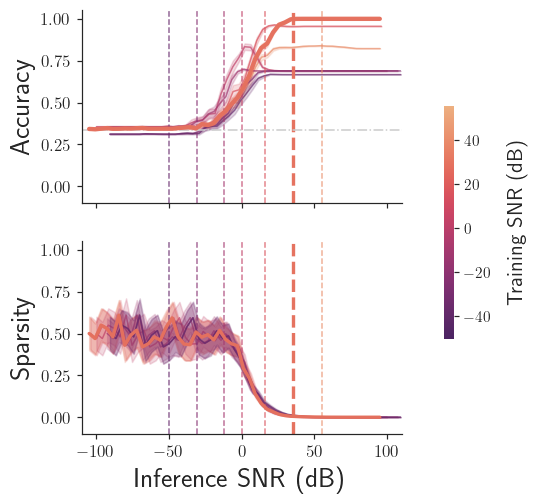

In [ ]:
# two pallens bottom: accuracy, top: sparsity
# fig = plt.figure(figsize=(5, 5))
# gs = fig.add_gridspec(2, 1, height_ratios=[0.5, 1], hspace=0.05)
# ax0 = fig.add_subplot(gs[0])
# ax1 = fig.add_subplot(gs[1], sharex=ax0)
flare_pal = sns.color_palette("flare", len(unique_train_snr))
crest_pal = sns.color_palette("crest", 7)
grey_pal = sns.color_palette("Greys", 7)

# adding colorbars to the right
norm = mpl.colors.Normalize(vmin=min_train_snr, vmax=max_train_snr)
sm = plt.cm.ScalarMappable(cmap="flare_r", norm=norm)
# sorted_snr_levels = sorted(snr_data['training_snr'].unique())
# num_levels = len(sorted_snr_levels)
# diff = jnp.diff(jnp.array(sorted_snr_levels), prepend=sorted_snr_levels[0]-1)
# boundaries = jnp.array(sorted_snr_levels) + diff/2
# boundaries = jnp.append(boundaries, sorted_snr_levels[-1] + diff/2)
# cmap = mpl.colors.ListedColormap(flare_pal.as_hex())
# norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

with sns.axes_style("ticks"):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, sharey=True, dpi=110)

    cbar = fig.colorbar(sm, ax=[ax1, ax2], location='right', pad=0.1, aspect=25, shrink=0.55)
    cbar.set_label("Training SNR (dB)", fontsize=14, labelpad=10)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10)

    for idx, train_snr in enumerate(snr_data['training_snr'].unique()):
        if train_snr == best_acc_train_snr:
            lw = 2.2
            alpha = 0.99
            data = snr_data.loc[snr_data['training_snr'] == train_snr]
            idx_plt = idx
            sns.lineplot(data=data, x='snr', y='accuracy', color=flare_pal[idx], ax=ax1, lw=lw*1.3, alpha=alpha, legend="full", err_style="band", zorder=10)
            sns.lineplot(data=data, x='snr', y='sparsity', color=flare_pal[idx], ax=ax2, lw=lw, alpha=alpha, legend=None, err_style="band", zorder=10)
            ax1.axvline(x=train_snr, color=flare_pal[idx], ls="--", lw=lw, alpha=alpha)
            ax2.axvline(x=train_snr, color=flare_pal[idx], ls="--", lw=lw, alpha=alpha)

        else:
            lw = 1.0
            alpha = 0.7
            data = snr_data.loc[snr_data['training_snr'] == train_snr]
            sns.lineplot(data=data, x='snr', y='accuracy', color=flare_pal[idx], ax=ax1, lw=lw, alpha=alpha, legend=None, err_style="band", zorder=1)
            sns.lineplot(data=data, x='snr', y='sparsity', color=flare_pal[idx], ax=ax2, lw=lw, alpha=alpha, legend=None, err_style="band", zorder=1)
            ax1.axvline(x=train_snr, color=flare_pal[idx], ls="--", lw=lw, alpha=alpha)
            ax2.axvline(x=train_snr, color=flare_pal[idx], ls="--", lw=lw, alpha=alpha)

    # adding the baseline accyracy line
    ax1.axhline(y=1/3, color="0.8", ls="-.", lw=1)
    # ax1.axvline(x=best_acc_train_snr, color=flare_pal[idx_plt], ls="--", lw=1.5)
    # ax2.axvline(x=best_acc_train_snr, color=flare_pal[idx_plt], ls="--", lw=1.5)

    ax1.set_ylim(-0.1, 1.05)
    ax2.set_ylim(-0.1, 1.05)
    ax2.set_xlim(-110, 110)

    # ax1.legend(frameon=False, title="Training SNR (dB)", fontsize=12)

    ax1.set_ylabel("Accuracy", fontsize=18)
    ax2.set_ylabel("Sparsity", fontsize=18)
    ax2.set_xlabel("Inference SNR (dB)", fontsize=18)

    ax1.tick_params(axis='both', labelsize=11)
    ax2.tick_params(axis='both', labelsize=11)

    sns.despine(ax=ax1)
    sns.despine(ax=ax2)

save_plot = False
figname = f"snr_acc_sparsity_{today}.pdf"
if save_plot:
    fig.savefig(os.path.join(FIGURES_PATH, figname), bbox_inches="tight", dpi=300, transparent=True)

In [119]:
print(idx_plt, best_acc_idx)

1 5000


## Plot the distributions of preactivations
- Pre-activations, expected states and sampled ternary activations

In [165]:
def gaussian_cdf(
        x: float,
        mean: float,
        std: float
):
    "Gaussian CDF"
    cdf = jax.scipy.stats.norm.cdf(x=x, loc=mean, scale=std)
    return cdf
 
 
# defining the expected state
def expected_state(
        x: float,
        threshold: float = 0.0,
        noise_std: float = 1.0,
        noise_mean: float = 0.0,
        **kwargs
    ):

    p = jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std)

    return 1 - 2*p


In [281]:
# load the preactivations dataset
preact_data = pickle.load(open(os.path.join(DATA_PATH, "models_preactivations_rms_2026-05-13.pkl"), "rb"))
print(preact_data.keys())
print(preact_data['model_name'])

mut_idx = 1 # model under test is the one with noise std = 0.1 
preacts = jnp.array(preact_data['preacts'][mut_idx])
preacts = preacts.reshape(32, -1) # reshapes into (datapoints, neurons)
print(f"Reshaped Preactivations shape: {preacts.shape}")

# computing the expected states
exp_states = jax.vmap(expected_state, in_axes=(0, None, None, None))(preacts, 0.0, preact_data['noise_std'][mut_idx], 0.0)

# computing the activations
keys = jax.random.key(45)
keys = jax.random.split(keys, len(preacts.flatten()))
activations = jax.vmap(dual_sample_ternary, in_axes=(0, 0, None, None, None))(preacts.flatten(), keys, 0.0, preact_data['noise_std'][mut_idx], 0.0)
activations = activations.reshape(preacts.shape)

# compute the training SNR for the model
training_snr = 20*jnp.log10(preact_data['rms_preactivation'][mut_idx]/preact_data['noise_std'][mut_idx])

print(f"Training SNR for the model: {training_snr:.4f} dB")
print(exp_states[0, :5])
print(activations[0, :5])

dict_keys(['model_name', 'model_index', 'rms_preactivation', 'preacts', 'noise_std'])
['/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.0010.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.0100.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_0.1000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_1.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_10.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_100.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-13_noise_1000.0000.pkl']
Reshaped Preactivations shape: (32, 150)
Training SNR for the model: 34.9807 dB
[-0.37415648 -1.         -1.          1.          1.        ]
[-1. -1. -1.  1.  1.]


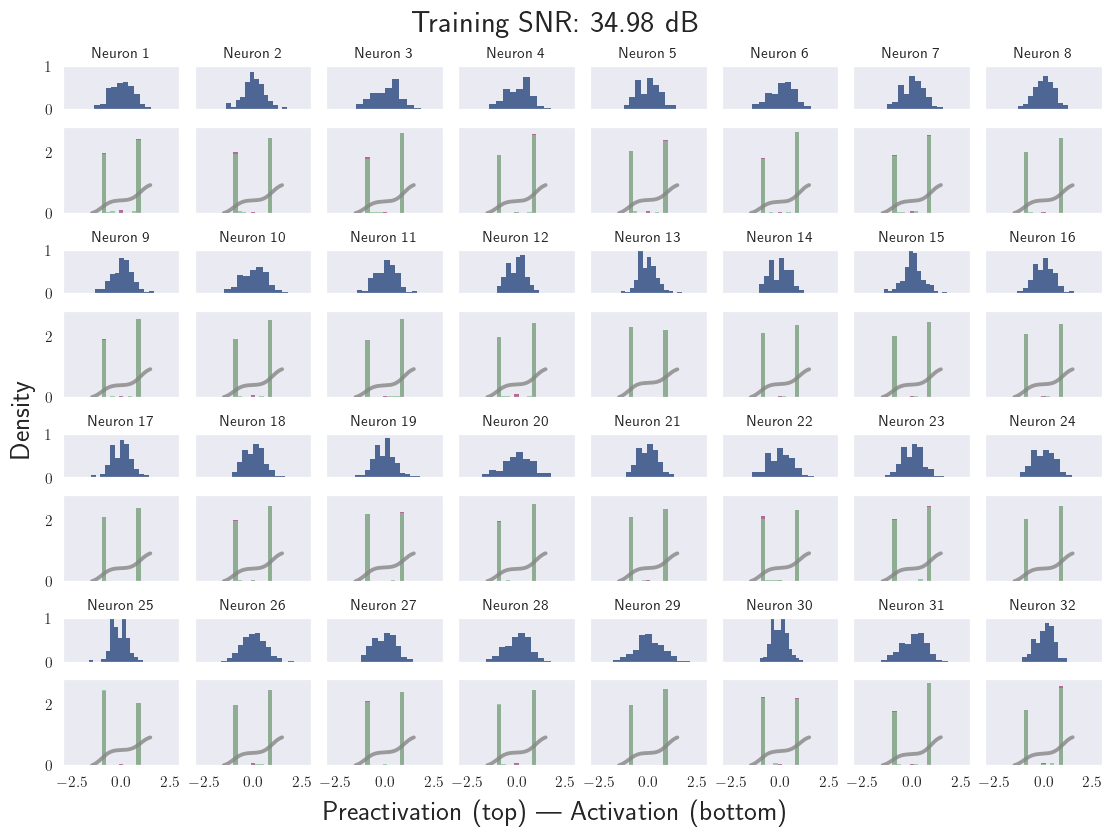

In [ ]:
flare_pal = sns.color_palette("flare", 8)
crest_pal = sns.color_palette("crest", 8)
grey_pal = sns.color_palette("Greys", 8)

fig = plt.figure(figsize=(10, 7.5), dpi=110, constrained_layout=True)
gs = fig.add_gridspec(
    ncols=8, 
    nrows=8,
    height_ratios=[1, 2.0]*4,
    hspace= 0.05,
    wspace=0.05
)

# plot the grid
ax_rect = []
ax_sq = []
anchor_top = None
anchor_bottom = None

with sns.axes_style("dark"):
    for r in range(4):
        for c in range(8):
            if r == 0 and c == 0:
                ax_top = fig.add_subplot(gs[2*r, c])
                ax_bottom = fig.add_subplot(gs[2*r+1, c])
                anchor_top = ax_top
                anchor_bottom = ax_bottom
            else:
                ax_top = fig.add_subplot(gs[2*r, c], sharex=anchor_top, sharey=anchor_top)
                ax_bottom = fig.add_subplot(gs[2*r+1, c], sharex=anchor_bottom, sharey=anchor_bottom)

            # store the axes in a list for later use
            ax_rect.append(ax_top)
            ax_sq.append(ax_bottom)


    for n in range(preacts.shape[0]):
        # Preactivation plots at the top
        sns.histplot(preacts[n, ...], 
                     color=crest_pal[-1],
                     stat='density',
                       alpha=0.8, 
                       ax=ax_rect[n], 
                       edgecolor=None, 
                       linewidth=0)
        
        
        # sns.histplot(exp_states[n, ...], 
        #              color=grey_pal[5],
        #              fill=False,
        #                alpha=0.7,
        #                stat='density', 
        #                ax=ax_tri[n],
        #                cumulative=True,
        #                edgecolor=None, 
        #                linewidth=0,
        #                kde=True,
        #             #    kde_kws={'clip': (-1, 1)}
        #             #    linewidth=0
        #                )
        
        sns.kdeplot(exp_states[n, ...],
                    cumulative=True,
                    color=grey_pal[4],
                    ax=ax_sq[n],
                    lw=2.5,
                    fill=False,
                    alpha=0.8,
                    zorder=10,
                    clip=(-1.5, 1.5)
        )


        # Activations and expected states at the bottom
        sns.histplot(activations[n, ...], 
                     color=flare_pal[5],
                       alpha=0.7, 
                       ax=ax_sq[n], 
                       stat="density", 
                       edgecolor=None, 
                       linewidth=0)
        
        sns.histplot(exp_states[n, ...], 
                     color=crest_pal[0],
                       alpha=0.8, 
                       ax=ax_sq[n], 
                       stat="density", 
                       edgecolor=None, 
                       linewidth=0)

        ax_sq[n].set_ylabel("")
        ax_rect[n].set_ylabel("")
        limits = [-3, 3]
        ax_sq[n].set_xlim(limits)
        ax_rect[n].set_xlim(limits)
        ax_rect[n].set_ylim(0, 1)
        # ax_preact[n].set_xlim(-3, 3)
        ax_rect[n].set_title(f"Neuron {n+1}", fontsize=10)

        # x-ticks
        if n < 24:
            ax_rect[n].tick_params(labelbottom=False)
            ax_sq[n].tick_params(labelbottom=False)
        else:
            ax_rect[n].tick_params(labelbottom=False)
            # ax_sq[n].tick_params(labelbottom=True)
            # xtick_list = [-2, -1, 0, 1, 2]
            # ax_sq[n].set_xticks(xtick_list)
            # ax_sq[n].set_xticklabels([r"${}$".format(x) for x in xtick_list], fontsize=10)

        # y-ticks
        if n%8 == 0:
            ax_rect[n].tick_params(labelleft=True)
            ax_sq[n].tick_params(labelleft=True)
        else:
            ax_rect[n].tick_params(labelleft=False)
            ax_sq[n].tick_params(labelleft=False)
            
    fig.supxlabel("Preactivation (top) | Activation (bottom)", fontsize=18)
    fig.supylabel("Density", fontsize=18)
    fig.suptitle(f"Training SNR: {training_snr:.02f} dB", fontsize=20)


save_plot = False
figname = f"pre-act-exp_distributions_snr_Train_{training_snr:.02f}_{today}.pdf"
if save_plot:
    fig.savefig(os.path.join(FIGURES_PATH, figname), bbox_inches="tight", dpi=300)